# Analysis notebook for LYNX ML Model

In [1]:
import numpy as np
import pandas as pd
import re
from collections import defaultdict
import matplotlib.pyplot as plt

In [2]:
DES_PARAM_VALUES = {
    "des_top_descriptor_reqs": [2, 4, 8, 16],
    "des_top_memloader_reqs": [16, 32, 64, 128],
    "des_cr_rocc_commands": [2, 4, 8],
    "des_dth_l1_reqs": [2, 4, 8, 16],
    "des_dth_fd_reqs": [2, 4, 8, 16],
    "des_dth_fd_resps": [2, 4, 8, 16],
    "des_fw_l1_reqs": [2, 4, 8, 16],
    "des_ml_buf_info_q": [8, 16, 32, 64],
    "des_ml_load_info_q": [128, 256, 512, 1024],
}

SER_PARAM_VALUES = {
    "ser_field_handlers": [2, 4, 6, 8],
    "ser_cr_rocc_commands": [2, 4, 6, 8],
    "ser_dth_hasbits_reqs": [2, 4, 8],
    "ser_dth_descriptor_reqs": [2, 4, 8, 16],
    "ser_dth_reg_resps": [5, 10, 20],
    "ser_dth_reqs_meta": [2, 4, 8, 16],
    "ser_dth_fh_outputs": [2, 4, 8, 16],
    "ser_mw_write_input": [2, 4, 8, 16],
    "ser_mw_write_inject": [2, 4, 8, 16],
    "ser_mw_write_ptrs": [5, 10, 20],
}

# Deserializer Simulation Results

In [45]:
df_ubuntu_results = pd.read_csv('sim_results/des_sweep_results_ubuntu_v1.csv')
df_rhel_results = pd.read_csv('sim_results/des_sweep_results_rhel_v1.csv')

In [46]:
print(df_ubuntu_results['bench'].value_counts())
print(df_rhel_results['bench'].value_counts())

bench
bench0    1580
bench1    1526
bench2    1450
bench3    1422
bench4    1366
bench5    1305
Name: count, dtype: int64
bench
bench0    1443
bench1    1388
bench2    1291
bench3    1275
bench4    1199
bench5    1131
Name: count, dtype: int64


## Construct combined results

In [47]:
config_columns = list(SER_PARAM_VALUES.keys()) + list(DES_PARAM_VALUES.keys())

In [48]:
program_columns = ['bench', 'op']

In [49]:
# Concatenate the two dataframes
combined_df = pd.concat([df_ubuntu_results, df_rhel_results], ignore_index=True)

# Check for duplicates across all columns
assert combined_df[program_columns + config_columns].drop_duplicates().shape[0] == combined_df.shape[0]

In [50]:
combined_df.to_csv('sim_results/des_combined_results.csv', index=False)

In [52]:
combined_df['op'].value_counts()

op
des    16376
Name: count, dtype: int64

## Construct unique config dataset

In [36]:
from collections import Counter

# For each unique config, randomly pick a benchmark such that the overall benchmark distribution is as uniform as possible.
# We'll use a greedy approach: for each config, assign it to the currently least-represented benchmark it possesses.

# First, find all unique configs (ignoring benchmark), mapping each config to possible benchmark rows
group_cols = config_columns
bench_choices_by_config = combined_df.groupby(group_cols)['bench'].unique().reset_index()
configs = bench_choices_by_config.to_dict(orient='records')

# Prepare data structure for mapping chosen config -> selected row
selected_row_indices = []
bench_count = Counter()

for conf in configs:
    # Get the boolean mask for all rows matching this config (across all benches)
    config_mask = (combined_df[group_cols] == pd.Series({k: conf[k] for k in group_cols})).all(axis=1)
    config_rows = combined_df[config_mask]
    benches = list(conf['bench'])
    # For each config, select the bench with current minimum count
    min_bench = min(benches, key=lambda b: bench_count[b])
    bench_count[min_bench] += 1
    # Select all rows for this (config, min_bench)
    selected = config_rows[config_rows['bench'] == min_bench]
    selected_row_indices.extend(selected.index.tolist())

# Build DataFrame (retaining all columns and all info for the selected rows)
unique_configs_df = combined_df.loc[selected_row_indices].reset_index(drop=True)
print(f'Shape of unique_configs_df: {unique_configs_df.shape}')

Shape of unique_configs_df: (3101, 30)


In [37]:
# Check if there are duplicates in the 'config_name' column
duplicates = unique_configs_df['config_name'].duplicated().any()
print(f"Are there duplicates in 'config_name'? {duplicates}")

Are there duplicates in 'config_name'? False


In [38]:
unique_configs_df.groupby('bench').size()

bench
bench0    517
bench1    517
bench2    517
bench3    517
bench4    517
bench5    516
dtype: int64

In [39]:
unique_configs_df.to_csv('sim_results/des_unique_configs.csv', index=False)

### Deserializer Onboarding Cost

In [3]:
summary_file = "sweep_results/ood_bench_onboarding_des/summary.txt"
with open(summary_file, "r") as f:
    summary = f.read()

deserializer_onboarding_cost = defaultdict(dict)
lines = summary.split("\n")
i = 0
while i < len(lines):
    line = lines[i]
    if "OOD benchmark: " in line:
        pat = r"OOD benchmark: ([^|]+) \| OOD train size: (\d+)"
        m = re.search(pat, line)
        if m:
            benchmark = m.group(1)
            ood_train_size = int(m.group(2))
            i += 1
            line = lines[i]
            percent_error = float(line.split("Final Percent Error: ")[1].split("%")[0].strip())
            deserializer_onboarding_cost[benchmark][ood_train_size] = percent_error
    i += 1

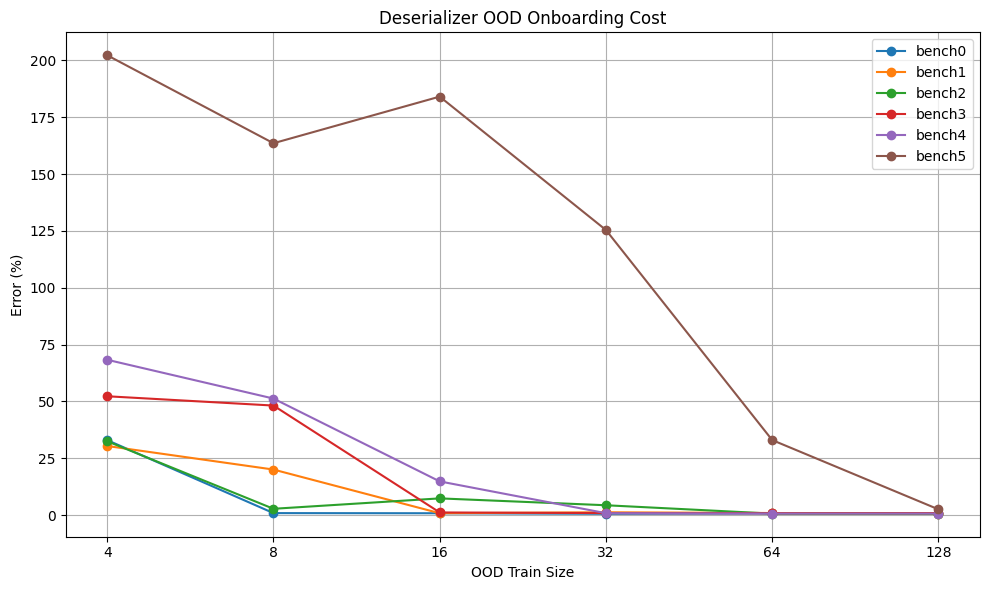

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))

# Include all benchmarks, including bench5
filtered_benchmarks = deserializer_onboarding_cost

# Filter out train_size=0 from all curve points and xticks
all_xs = sorted({x for benchmark, errors in filtered_benchmarks.items() for x in errors.keys() if x != 0})
x_positions = np.arange(len(all_xs))
x_lookup = {x: i for i, x in enumerate(all_xs)}

for benchmark, errors in filtered_benchmarks.items():
    xs = sorted([x for x in errors.keys() if x != 0])
    ys = [errors[x] for x in xs]
    positions = [x_lookup[x] for x in xs]
    ax.plot(positions, ys, marker='o', label=benchmark)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(all_xs)
ax.set_xlabel("OOD Train Size")
ax.set_ylabel("Error (%)")
ax.set_title("Deserializer OOD Onboarding Cost")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/ood_bench_onboarding_des/onboarding_cost_with_bench5.png", bbox_inches='tight')

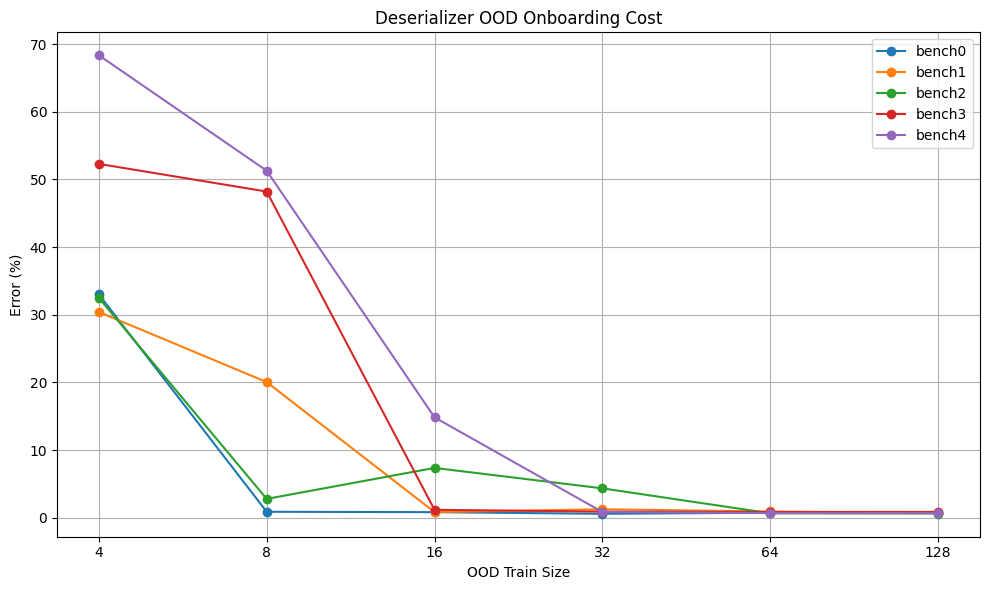

In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

# Ignore "bench5" everywhere
filtered_benchmarks = {b: e for b, e in deserializer_onboarding_cost.items() if b != "bench5"}

# Filter out train_size=0 from all curve points and xticks
all_xs = sorted({x for benchmark, errors in filtered_benchmarks.items() for x in errors.keys() if x != 0})
x_positions = np.arange(len(all_xs))
x_lookup = {x: i for i, x in enumerate(all_xs)}

for benchmark, errors in filtered_benchmarks.items():
    xs = sorted([x for x in errors.keys() if x != 0])
    ys = [errors[x] for x in xs]
    positions = [x_lookup[x] for x in xs]
    ax.plot(positions, ys, marker='o', label=benchmark)

# ax.set_yscale('log')
ax.set_xticks(x_positions)
ax.set_xticklabels(all_xs)
ax.set_xlabel("OOD Train Size")
ax.set_ylabel("Error (%)")
ax.set_title("Deserializer OOD Onboarding Cost")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig("sweep_results/ood_bench_onboarding_des/onboarding_cost_without_bench5.png", bbox_inches='tight')

# Serializer Simulation Results

In [40]:
df_ubuntu_results = pd.read_csv('sim_results/ser_sweep_results_ubuntu_v1.csv')
df_rhel_results = pd.read_csv('sim_results/ser_sweep_results_rhel_v1.csv')

## Construct combined results

In [41]:
config_columns = list(SER_PARAM_VALUES.keys()) + list(DES_PARAM_VALUES.keys())

In [42]:
program_columns = ['bench', 'op']

In [43]:
# Concatenate the two dataframes
combined_df = pd.concat([df_ubuntu_results, df_rhel_results], ignore_index=True)

# Check for duplicates across all columns
assert combined_df[program_columns + config_columns].drop_duplicates().shape[0] == combined_df.shape[0]

In [44]:
combined_df.to_csv('sim_results/ser_combined_results.csv', index=False)